In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qm import SimulationConfig
from qm.qua import *
import os
import xarray as xr
import json
from quam_libs.components import QuAM
from quam_libs.lib.save_utils import find_numbered_folder

2025-12-10 12:51:47,945 - qm - INFO     - Starting session: d8797f48-08b4-48c9-b258-5268edd17c41


/Users/mohammadkashani/Documents/Qolab/qolab-start/.venv/lib/python3.11/site-packages/qm/results/__init__.py:15: DeprecationWarning: qm.results is deprecated since "1.2.3" and will be removed in "1.3.0". If you need anything from this module, import it directly from `qm` or from `qm.simulate` for simulator-related functionality.
  warnings.warn(


In [3]:
def load_dataset(serial_number, target_filename = "ds", parameters = None):
    """
    Loads a dataset from a file based on the serial number.
    
    Args:
        serial_number: The serial number to search for.
        base_folder: The base directory to search in.
    
    Returns:
        An xarray Dataset if found, None otherwise.
    """
    if not isinstance(serial_number, int):
        raise ValueError("serial_number must be an integer")
        
    base_folder = "/Users/mohammadkashani/Documents/Qolab/qolab-start/data/"
    for subfolder in os.listdir(base_folder):
        if os.path.isdir(os.path.join(base_folder, subfolder)):
            for subfolder_2 in os.listdir(os.path.join(base_folder, subfolder)):
                if '#'+str(serial_number) in os.path.basename(subfolder_2):
                    base_folder = os.path.join(base_folder, subfolder, subfolder_2)
                    break
    print(f"Searching in folder: {base_folder}")
        
    print(f"Loading data from folder: {base_folder}")
    # Look for .nc files in the subfolder
    nc_files = [f for f in os.listdir(base_folder) if f.endswith('.h5')]
    print(nc_files)
    # look for filename.h5
    is_present = target_filename in [file.split('.')[0] for file in nc_files]
    filename = [file for file in nc_files if target_filename == file.split('.')[0]][0] if is_present else None
    json_filename = "data.json"
    
    if nc_files:
        # Assuming there's only one .nc file per folder
        file_path = os.path.join(base_folder, filename)
        json_path = os.path.join(base_folder, json_filename)
        # Open the dataset
        print(f"Loading dataset from file: {file_path}")
        ds = xr.open_dataset(file_path)
        with open(json_path, 'r') as f:
            json_data = json.load(f)
        try:
            machine = QuAM.load(base_folder + "/quam_state/state.json")
        except Exception as e:
            print(f"Error loading machine: {e}")
            machine = None
        qubits = [machine.qubits[qname] for qname in ds.qubit.values]    
        if parameters is not None:
            for param_name, param_value in parameters:
                if param_name != "load_data_id":
                    if param_name in json_data["initial_parameters"]:
                        setattr(parameters, param_name, json_data["initial_parameters"][param_name])
            return ds, machine, json_data, qubits,parameters
        else:
            return ds, machine, json_data, qubits
    else:
        print(f"No .nc file found in folder: {base_folder}")
        return None


Searching in folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-12/#495_02a_Resonator_Spectroscopy_141533
Loading data from folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-12/#495_02a_Resonator_Spectroscopy_141533
['ds.h5']
Loading dataset from file: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-12/#495_02a_Resonator_Spectroscopy_141533/ds.h5
Searching in folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-12/#499_02a_Resonator_Spectroscopy_144122
Loading data from folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-12/#499_02a_Resonator_Spectroscopy_144122
['ds.h5']
Loading dataset from file: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-12/#499_02a_Resonator_Spectroscopy_144122/ds.h5
Searching in folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-12/#501_02a_Resonator_Spectroscopy_145218
Loading data from folder: /Users/mohammadkashani/Document

Searching in folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-12/#504_02a_Resonator_Spectroscopy_151748 |0>
Loading data from folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-12/#504_02a_Resonator_Spectroscopy_151748 |0>
['ds.h5']
Loading dataset from file: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-12/#504_02a_Resonator_Spectroscopy_151748 |0>/ds.h5
Searching in folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-12/#503_02a_Resonator_Spectroscopy_151112 |1>
Loading data from folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-12/#503_02a_Resonator_Spectroscopy_151112 |1>
['ds.h5']
Loading dataset from file: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-12/#503_02a_Resonator_Spectroscopy_151112 |1>/ds.h5
Searching in folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-12/#502_02a_Resonator_Spectroscopy_150515 |2>
Loading data from folder: /Us

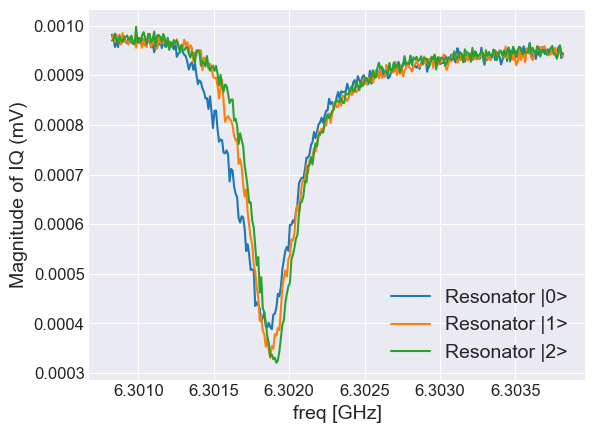

In [53]:
resonator_0 = load_dataset(504)
resonator_1 = load_dataset(503)
resonator_2 = load_dataset(502)

IQ_res_1 = resonator_0[0].I.sel(qubit="q4") + 1j*resonator_0[0].Q.sel(qubit="q4")
IQ_res_2 =resonator_1[0].I.sel(qubit="q4") + 1j*resonator_1[0].Q.sel(qubit="q4")
IQ_res_3 =resonator_2[0].I.sel(qubit="q4") + 1j*resonator_2[0].Q.sel(qubit="q4")

x_0 = (resonator_0[0].freq_full / 1e9).loc['q4']
x_1 = (resonator_1[0].freq_full / 1e9).loc['q4']
x_2 = (resonator_2[0].freq_full / 1e9).loc['q4']

plt.plot(x_0,np.abs(IQ_res_1) , label="Resonator |0>")
plt.plot(x_1,np.abs(IQ_res_2) , label="Resonator |1>")
plt.plot(x_2,np.abs(IQ_res_3) , label="Resonator |2>")
plt.xlabel("freq [GHz]", fontsize=14)
plt.ylabel("Magnitude of IQ (mV)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=14)
plt.show()  

Searching in folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-12/#521_07a_Readout_Frequency_Optimization_203316
Loading data from folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-12/#521_07a_Readout_Frequency_Optimization_203316
['ds.h5']
Loading dataset from file: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-12/#521_07a_Readout_Frequency_Optimization_203316/ds.h5


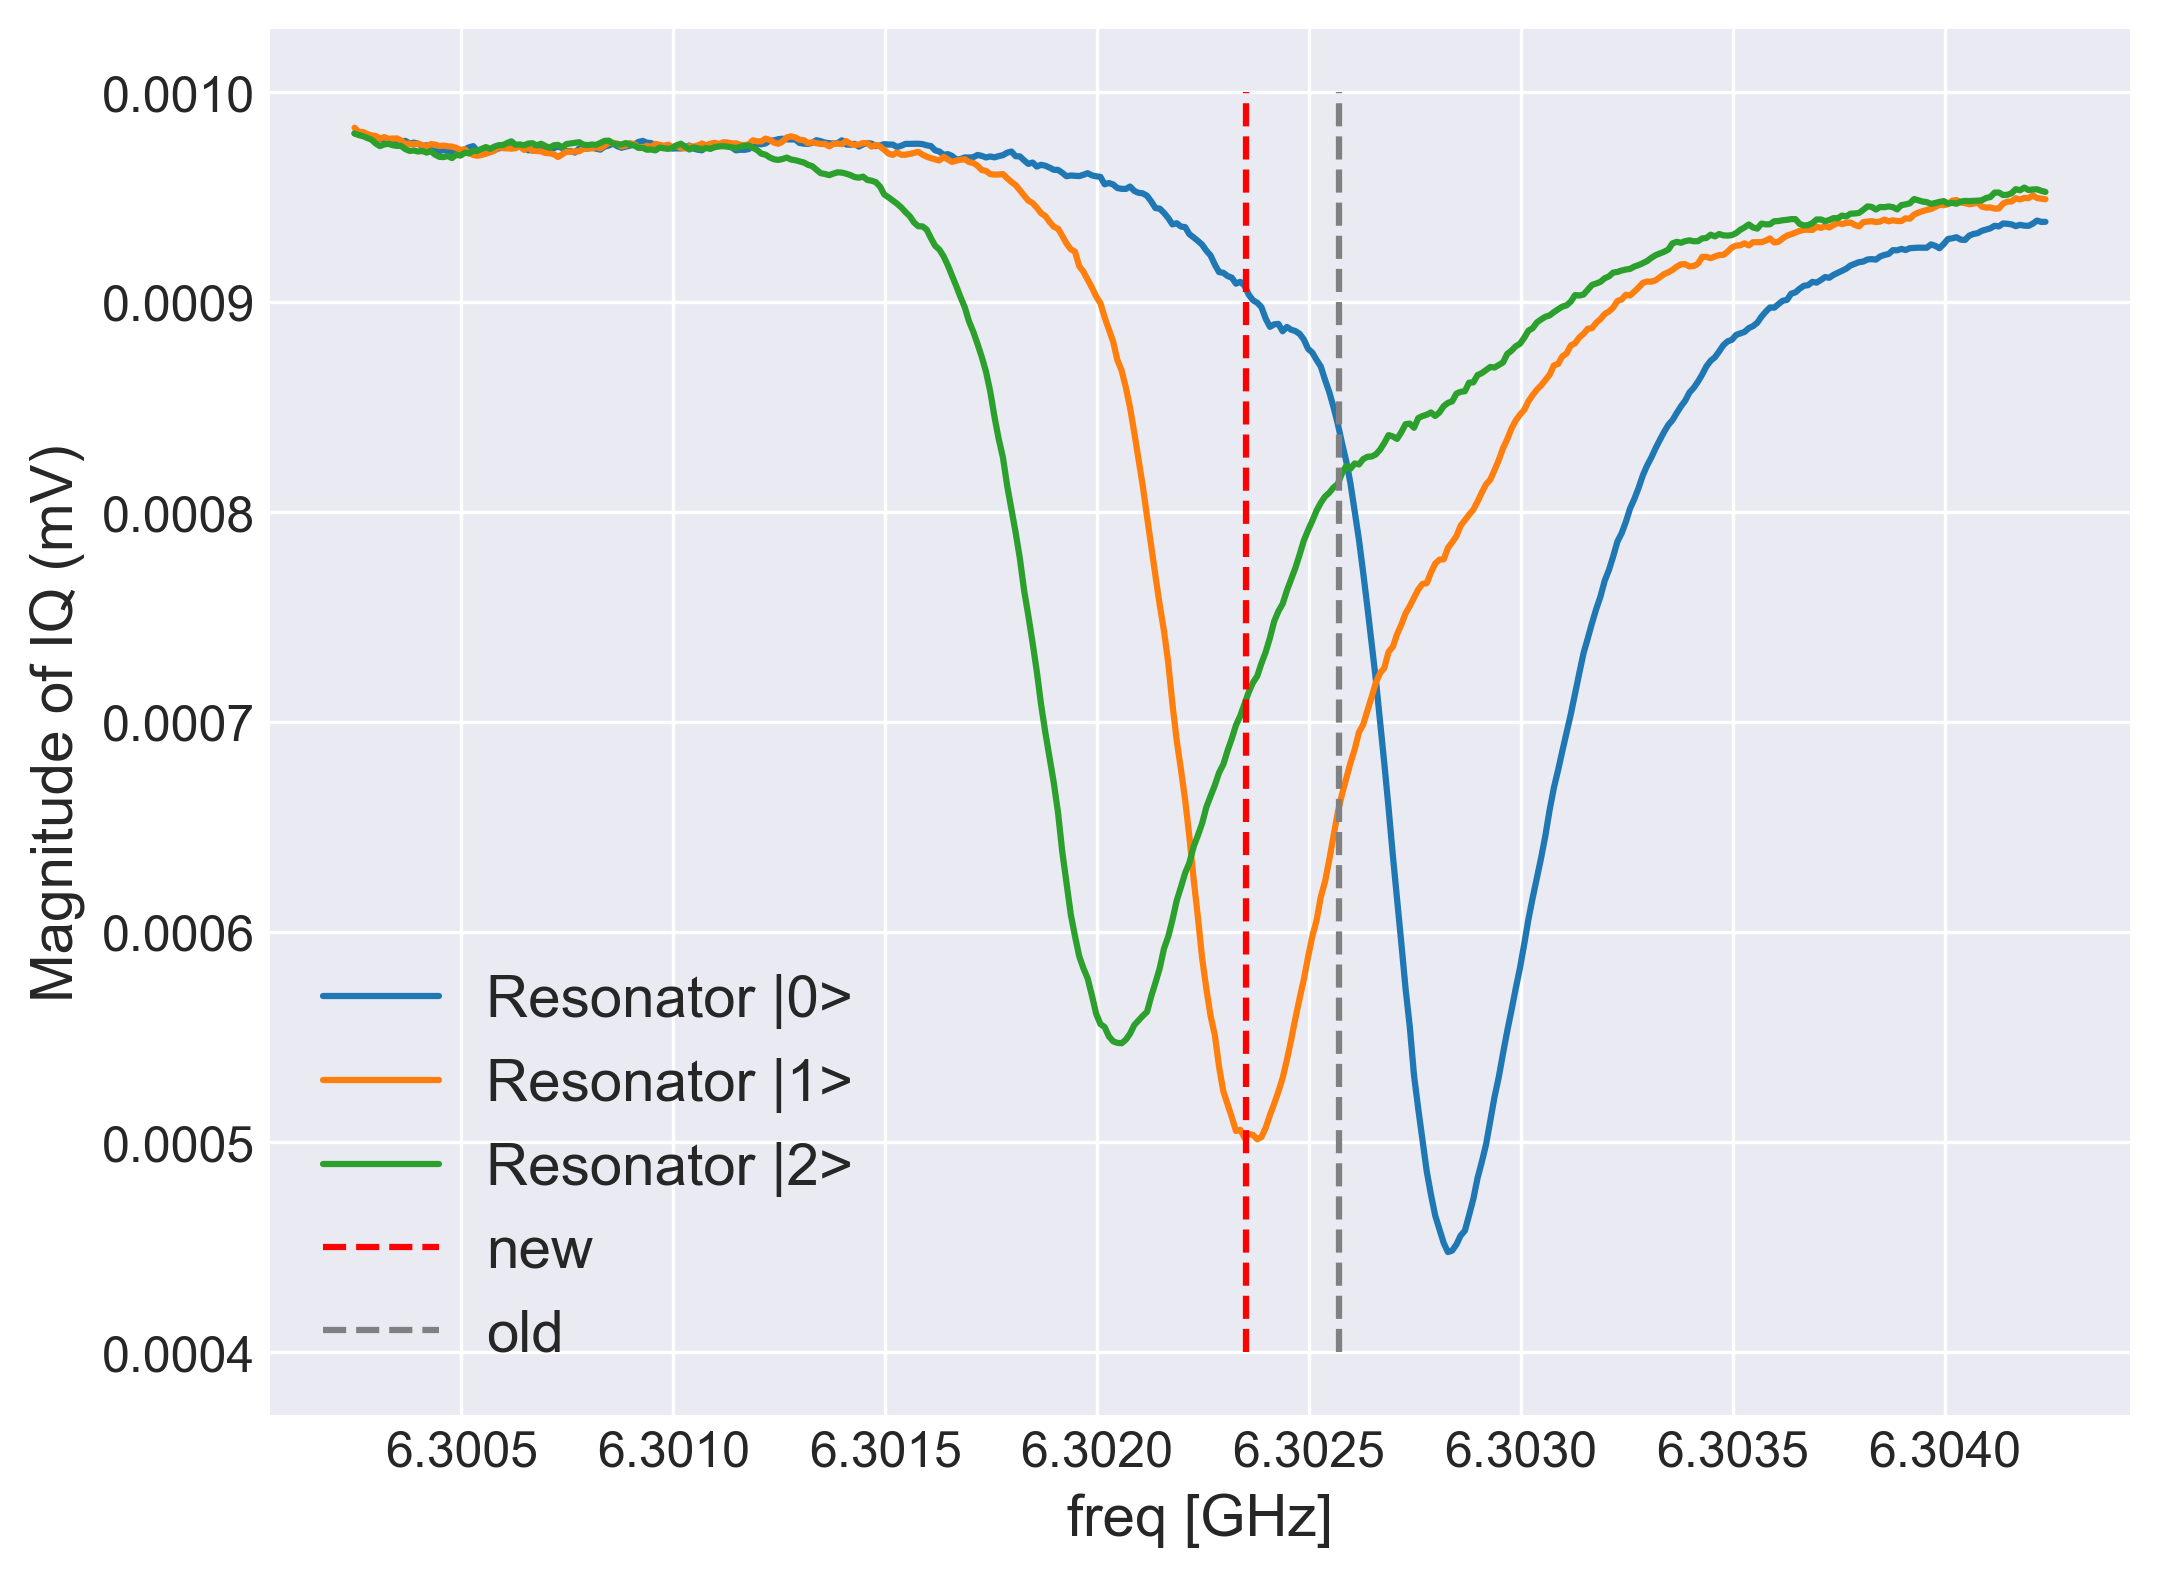

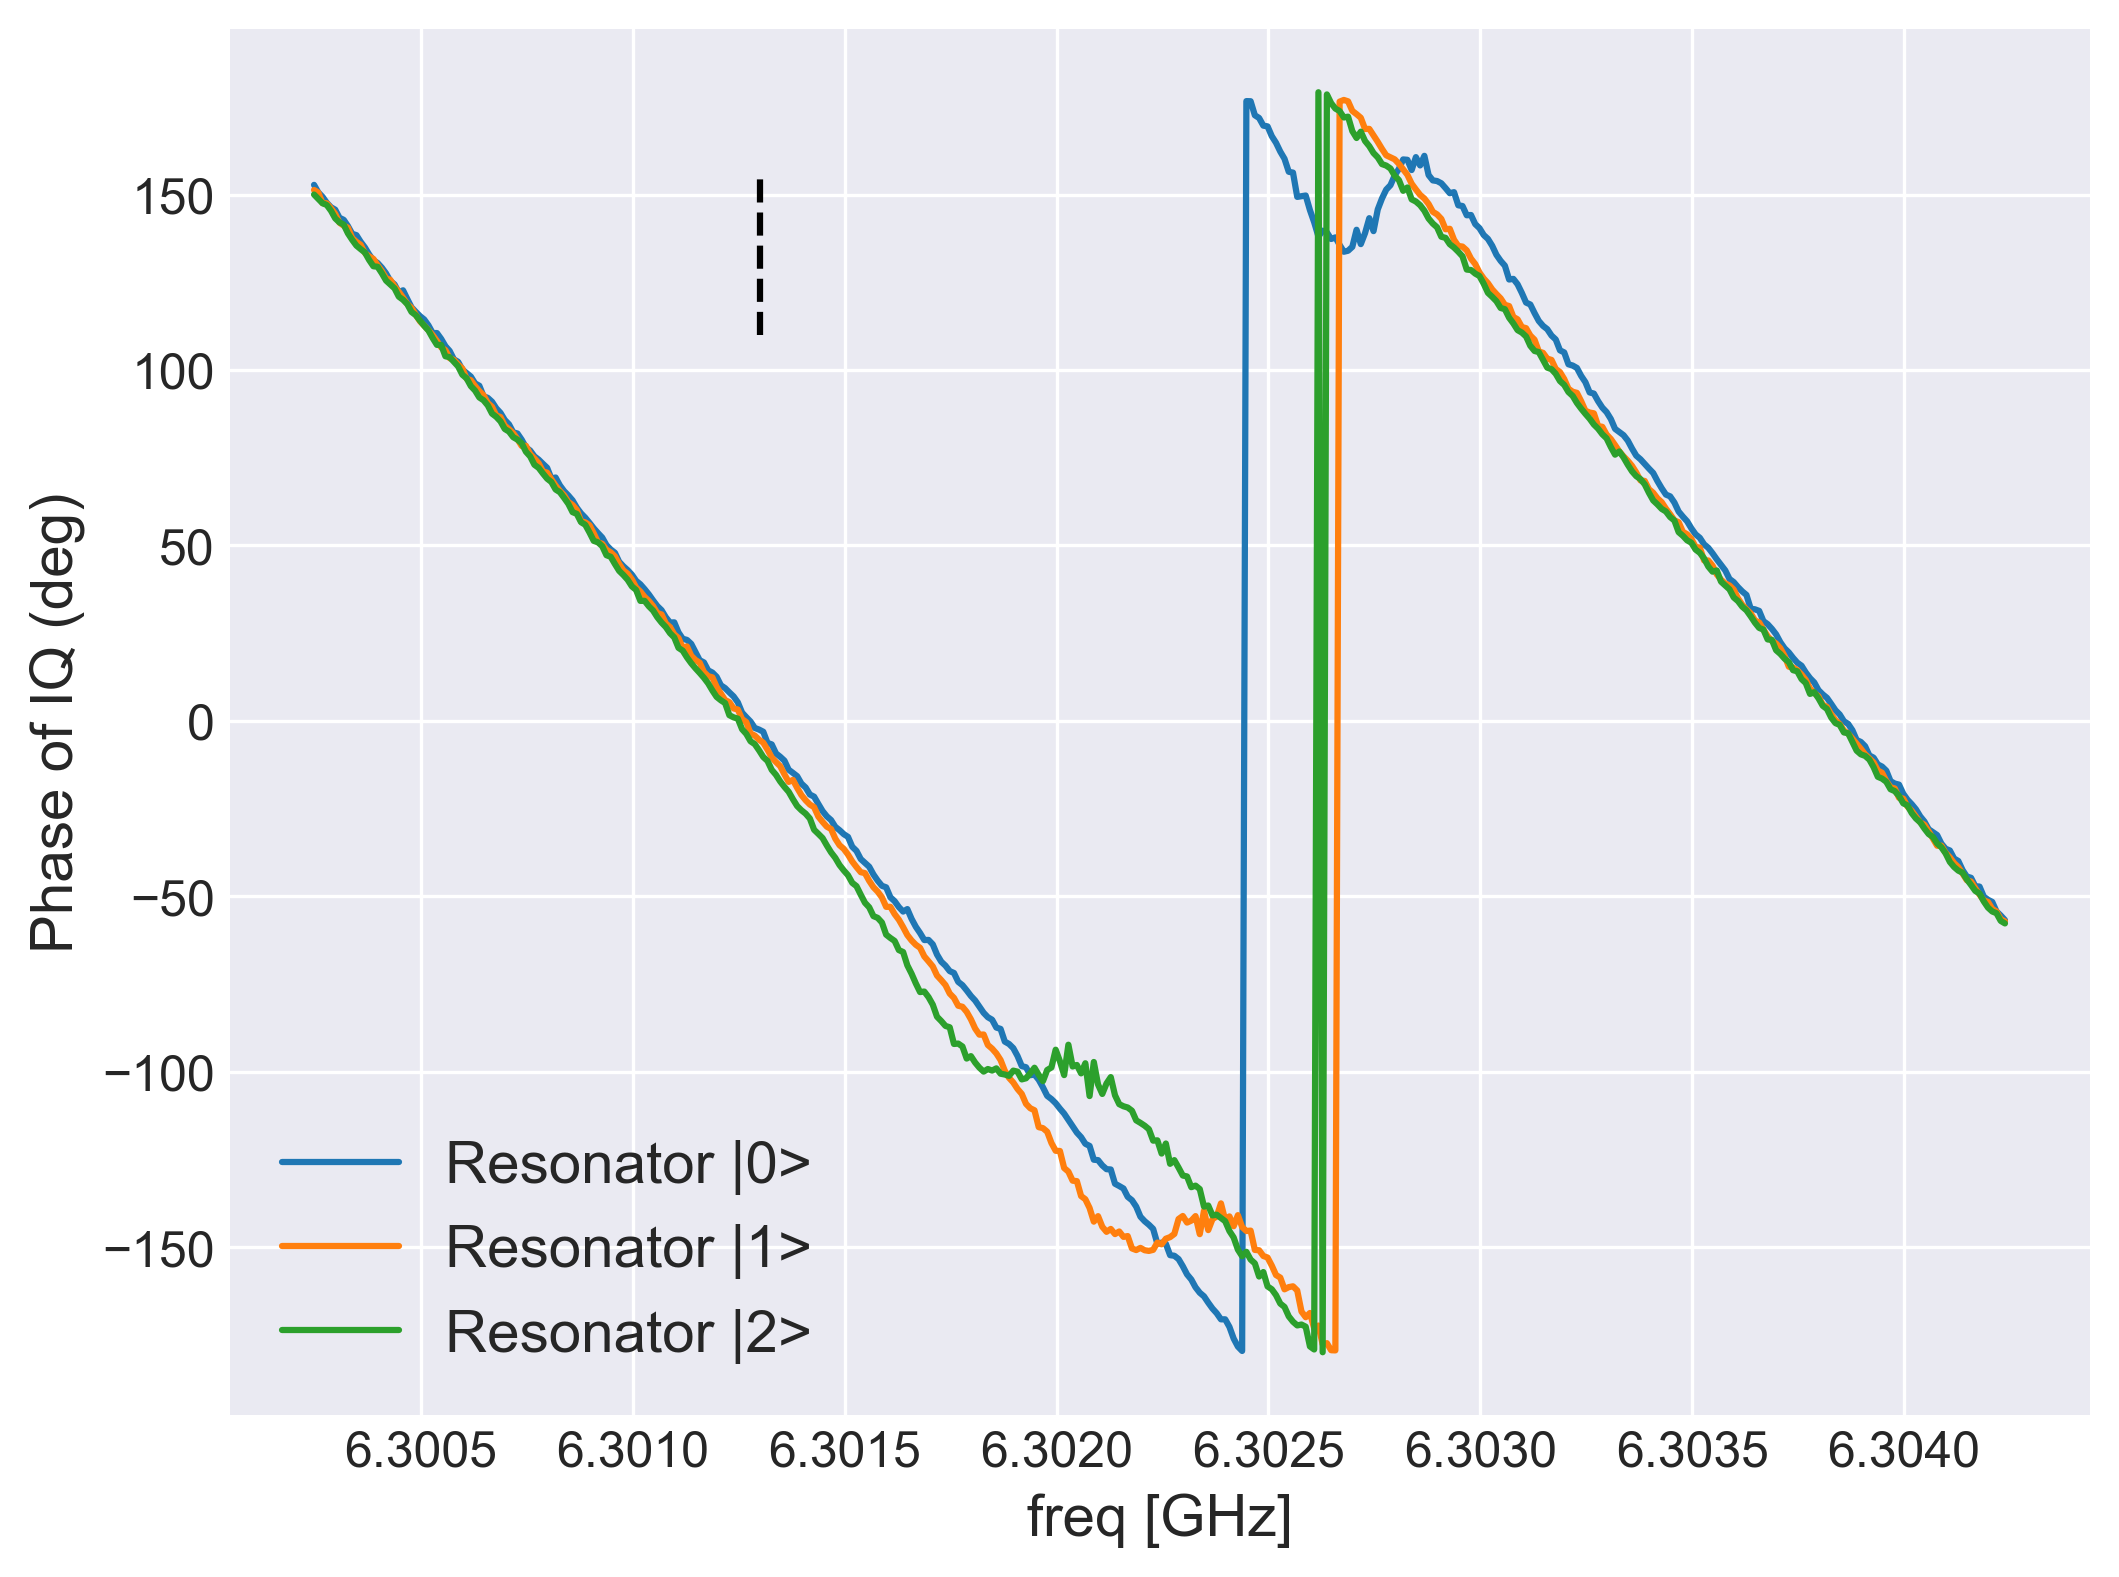

-52351000.0

In [88]:
def lpf(x, alpha=0.1):
    y = np.zeros_like(x)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i - 1]
    return y

resonator = load_dataset(521)[0]

IQ_res_0 = resonator.I_g.sel(qubit="q4") + 1j*resonator.Q_g.sel(qubit="q4")
IQ_res_1 = resonator.I_e.sel(qubit="q4") + 1j*resonator.Q_e.sel(qubit="q4")
IQ_res_2 = resonator.I_f.sel(qubit="q4") + 1j*resonator.Q_f.sel(qubit="q4")

x = (resonator.freq_full / 1e9).loc['q4']

plt.figure(figsize=(8,6), dpi=300)
plt.plot(x,lpf(np.abs(IQ_res_0)) , label="Resonator |0>")
plt.plot(x,lpf(np.abs(IQ_res_1)) , label="Resonator |1>")
plt.plot(x,lpf(np.abs(IQ_res_2)) , label="Resonator |2>")
plt.xlabel("freq [GHz]", fontsize=14)
plt.ylabel("Magnitude of IQ (mV)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.vlines(6.302351e9/1e9, ymin=0.0004, ymax=0.001, colors='red', linestyles='dashed', label='new')
plt.vlines(6.302570e9/1e9, ymin=0.0004, ymax=0.001, colors='grey', linestyles='dashed', label='old')
plt.legend(fontsize=14)
302570e9 - 302248e9
plt.show()


plt.figure(figsize=(8,6), dpi=300)
plt.plot(x,np.angle(IQ_res_0, deg=True) , label="Resonator |0>")
plt.plot(x,np.angle(IQ_res_1, deg=True) , label="Resonator |1>")
plt.plot(x,np.angle(IQ_res_2, deg=True) , label="Resonator |2>")
plt.legend(fontsize=14)
plt.xlabel("freq [GHz]", fontsize=14)
plt.ylabel("Phase of IQ (deg)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.vlines(6.3013e9/1e9, ymin=110, ymax=155, colors='k', linestyles='dashed', label='Readout freq')
plt.show()  
# 302570e9 - 302248e9
6250000000 - 6.302351e9

In [89]:
load_dataset(521)[0]

Searching in folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-12/#521_07a_Readout_Frequency_Optimization_203316
Loading data from folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-12/#521_07a_Readout_Frequency_Optimization_203316
['ds.h5']
Loading dataset from file: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-12/#521_07a_Readout_Frequency_Optimization_203316/ds.h5


<xarray.Dataset> Size: 38kB
Dimensions:    (freq: 400, qubit: 1)
Coordinates:
  * freq       (freq) float64 3kB -2e+06 -1.99e+06 ... 1.98e+06 1.99e+06
    freq_full  (qubit, freq) float64 3kB ...
  * qubit      (qubit) object 8B 'q4'
Data variables:
    I_g        (qubit, freq) float64 3kB ...
    Q_e        (qubit, freq) float64 3kB ...
    Q_f        (qubit, freq) float64 3kB ...
    I_f        (qubit, freq) float64 3kB ...
    I_e        (qubit, freq) float64 3kB ...
    Q_g        (qubit, freq) float64 3kB ...
    D          (qubit, freq) float64 3kB ...
    IQ_abs_g   (qubit, freq) float64 3kB ...
    IQ_abs_e   (qubit, freq) float64 3kB ...
    IQ_abs_f   (qubit, freq) float64 3kB ...

# Load Old Data
To load old data, we use the `load_dataset` command with the serial number of the dataset. The serial number is the number of the experiment in the `data` tab of the `qualibrate` dashboard; also, it is the numbers coming directly after the `#` in the `data` sub-folders.

Here are the relevant experiments we will look at in this assignment:
- 65: Experiment number 65 was the 'bad' data we took in class for IQ Blobs on 2025-10-13;
- 71: Experiment number 71 was the 'good' data I showed in class for IQ Blobs (taken on 2025-10-14); 
- 58: Experiment number 58 was the 'bad' data we took in class for T1 on 2025-10-13; 
- 70: Experiment number 70 was the 'good' data I showed in class for T1 (taken on 2025-10-14).

Other experiments are provided in the data folder for you to peruse. The qolab-start provided data analysis can be applied to old data, even without a token, by navigating to the associated node in node library and putting in the data ID in the `Load Data ID` field. For example, experiment 54 was qubit spectroscopy (see `data/2025-10-13/#54_03a_Qubit_Spectroscopy_153559/`). Navigating to the node library, node `03a_Qubit_Spectroscopy` and putting in experiment 54 into `Load Data ID` will allow you to run the analysis on the old data (reproducing the plot that is already in the data tab for experiment 54). This will be useful when we make want to make new nodes that operate on the same experimental data. Note that all of the nodes are defined in `code/calibration_graph/`. New nodes can be added here; old nodes can adjusted. It can also be helpful to look there to see how the fits are currently done. This might help you with the below assignment.

I provide two example dataset loading and plotting to help for the problems.

In [4]:
b = load_dataset(472)
b[0]

Searching in folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-01/#472_04_Power_Rabi_state_2_184656
Loading data from folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-01/#472_04_Power_Rabi_state_2_184656
['ds.h5']
Loading dataset from file: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-01/#472_04_Power_Rabi_state_2_184656/ds.h5


<xarray.Dataset> Size: 21kB
Dimensions:  (amp: 650, qubit: 1)
Coordinates:
  * amp      (amp) float64 5kB 0.0 0.01 0.02 0.03 0.04 ... 6.46 6.47 6.48 6.49
    abs_amp  (qubit, amp) float64 5kB ...
  * qubit    (qubit) object 8B 'q3'
Data variables:
    I        (qubit, amp) float64 5kB ...
    Q        (qubit, amp) float64 5kB ...

Searching in folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-01/#472_04_Power_Rabi_state_2_184656
Loading data from folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-01/#472_04_Power_Rabi_state_2_184656
['ds.h5']
Loading dataset from file: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-01/#472_04_Power_Rabi_state_2_184656/ds.h5


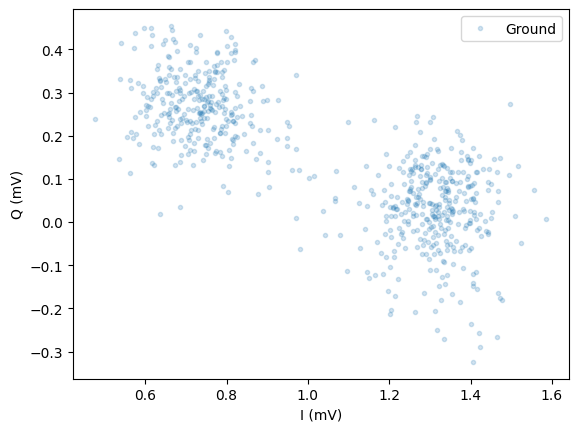

In [5]:
b = load_dataset(472)
plt.plot(1e3*b[0].I.sel(qubit="q3").values,1e3*b[0].Q.sel(qubit="q3"),".",alpha=0.2,label="Ground")
# plt.plot(1e3*b[0].I.sel(qubit="q4").values,1e3*b[0].Q.sel(qubit="q4"),".",alpha=0.2,label="Excited")
plt.xlabel("I (mV)")
plt.ylabel("Q (mV)")
plt.legend()

Searching in folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-01/#394_04_Power_Rabi_state_2_092655
Loading data from folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-01/#394_04_Power_Rabi_state_2_092655
['ds.h5']
Loading dataset from file: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-01/#394_04_Power_Rabi_state_2_092655/ds.h5


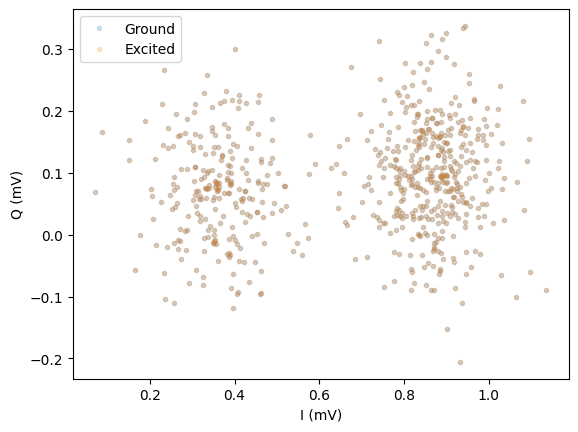

In [6]:
b = load_dataset(394)
plt.plot(1e3*b[0].I.sel(qubit="q4").values,1e3*b[0].Q.sel(qubit="q4"),".",alpha=0.2,label="Ground")
plt.plot(1e3*b[0].I.sel(qubit="q4").values,1e3*b[0].Q.sel(qubit="q4"),".",alpha=0.2,label="Excited")
plt.xlabel("I (mV)")
plt.ylabel("Q (mV)")
plt.legend()

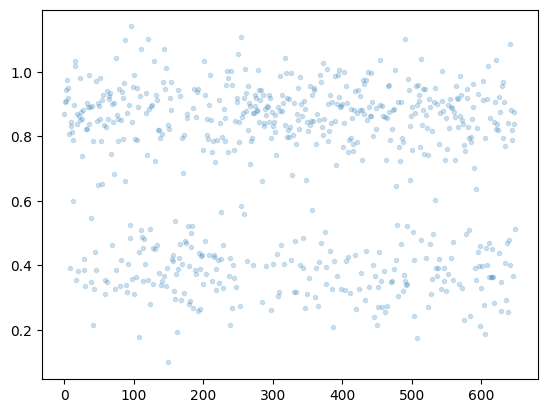

In [7]:
plt.plot(np.abs(1e3*b[0].I.sel(qubit="q4").values + 1e3*b[0].Q.sel(qubit="q4")*1j),".",alpha=0.2,label="Ground")


In [8]:
np.abs(1+2j)

2.23606797749979

Searching in folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-11-30/#289_03b_Qubit_ef_Spectroscopy_191748
Loading data from folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-11-30/#289_03b_Qubit_ef_Spectroscopy_191748
['ds.h5']
Loading dataset from file: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-11-30/#289_03b_Qubit_ef_Spectroscopy_191748/ds.h5


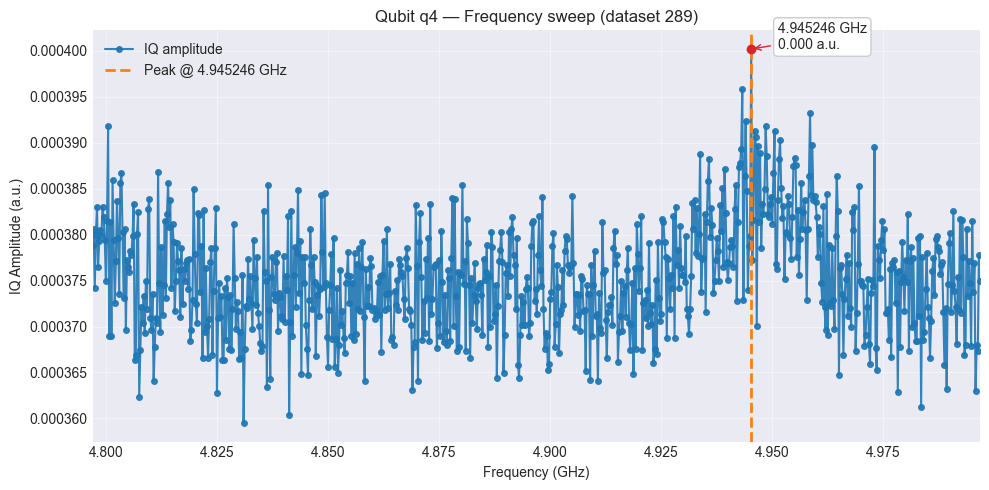

In [9]:
a = load_dataset(289)
# Beautiful frequency sweep plot for qubit q4 (dataset 289)
# try:
plt.style.use("seaborn-v0_8-darkgrid")

# Extract arrays
freq_arr = np.asarray(a[0].freq_full[0].values) / 1e9  # GHz
iq_arr = np.asarray(a[0].IQ_abs.sel(qubit="q4").values).squeeze()

# Find peak
peak_idx = int(np.nanargmax(iq_arr))
peak_freq = freq_arr[peak_idx]
peak_iq = float(iq_arr[peak_idx])

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(freq_arr, iq_arr, marker="o", markersize=4, linestyle="-", color="#1f77b4", alpha=0.9, label="IQ amplitude")
ax.axvline(peak_freq, color="#ff7f0e", linestyle="--", linewidth=2, label=f"Peak @ {peak_freq:.6f} GHz")
ax.scatter([peak_freq], [peak_iq], color="#d62728", zorder=5)

# Annotation
ax.annotate(f"{peak_freq:.6f} GHz\n{peak_iq:.3f} a.u.",
            xy=(peak_freq, peak_iq),
            xytext=(peak_freq + (freq_arr.max() - freq_arr.min()) * 0.03, peak_iq),
            arrowprops=dict(arrowstyle="->", color="#d62728"),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#cccccc"))

# Labels and style
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("IQ Amplitude (a.u.)")
ax.set_title("Qubit q4 — Frequency sweep (dataset 289)")
ax.legend(loc="best")
ax.set_xlim(freq_arr.min(), freq_arr.max())
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# except Exception as e:
#     print(f"Could not plot q4: {e}")



Searching in folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-11-30/#290_04_Power_Rabi_state_2_191924
Loading data from folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-11-30/#290_04_Power_Rabi_state_2_191924
['ds.h5']
Loading dataset from file: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-11-30/#290_04_Power_Rabi_state_2_191924/ds.h5


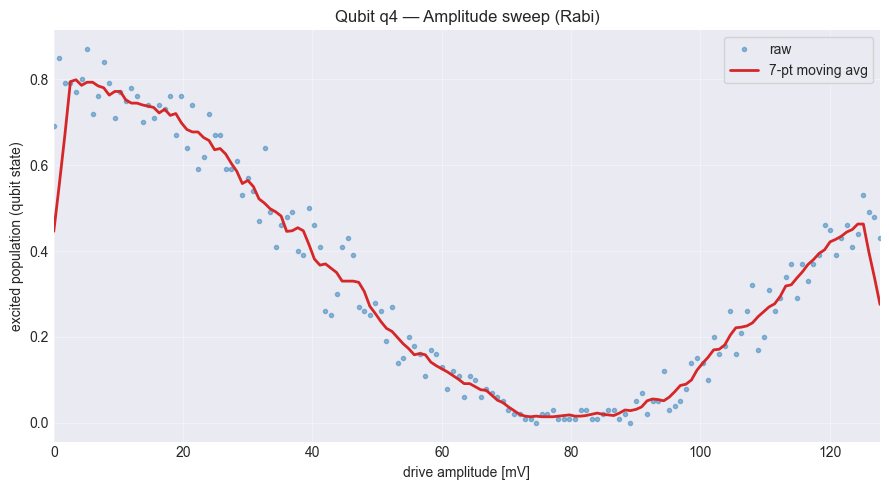

In [10]:
a = load_dataset(290)
a[0]

# IQ = a[0].I.sel(qubit="q4") + 1j*a[0].Q.sel(qubit="q4")
amp = a[0].abs_amp.sel(qubit="q4")
state = a[0].state.sel(qubit="q4")

# improved plot for amplitude sweep (uses amp and state defined above)
amp_mV = 1e3 * amp.values  # convert to mV
state_vals = state.values

# simple smoothing (moving average)
window = 7
kernel = np.ones(window) / window
state_smooth = np.convolve(state_vals, kernel, mode="same")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(amp_mV, state_vals, '.', color="#1f77b4", alpha=0.45, label="raw")
ax.plot(amp_mV, state_smooth, '-', color="#d62728", linewidth=2, label=f"{window}-pt moving avg")

# mark peak (maximum excited population)
# peak_idx = int(np.nanargmax(state_smooth))
# ax.scatter(amp_mV[peak_idx], state_smooth[peak_idx], color="#2ca02c", s=80, zorder=5,
#            label=f"peak @ {amp_mV[peak_idx]:.2f} mV")

ax.set_xlabel("drive amplitude [mV]")
ax.set_ylabel("excited population (qubit state)")
ax.set_title("Qubit q4 — Amplitude sweep (Rabi)")
ax.grid(alpha=0.35)
ax.legend(frameon=True)
ax.set_xlim(amp_mV.min(), amp_mV.max())
plt.tight_layout()
plt.show()


Searching in folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-12/#523_07d_IQ_Blobs_3state_204849
Loading data from folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-12/#523_07d_IQ_Blobs_3state_204849
['ds.h5']
Loading dataset from file: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-12-12/#523_07d_IQ_Blobs_3state_204849/ds.h5


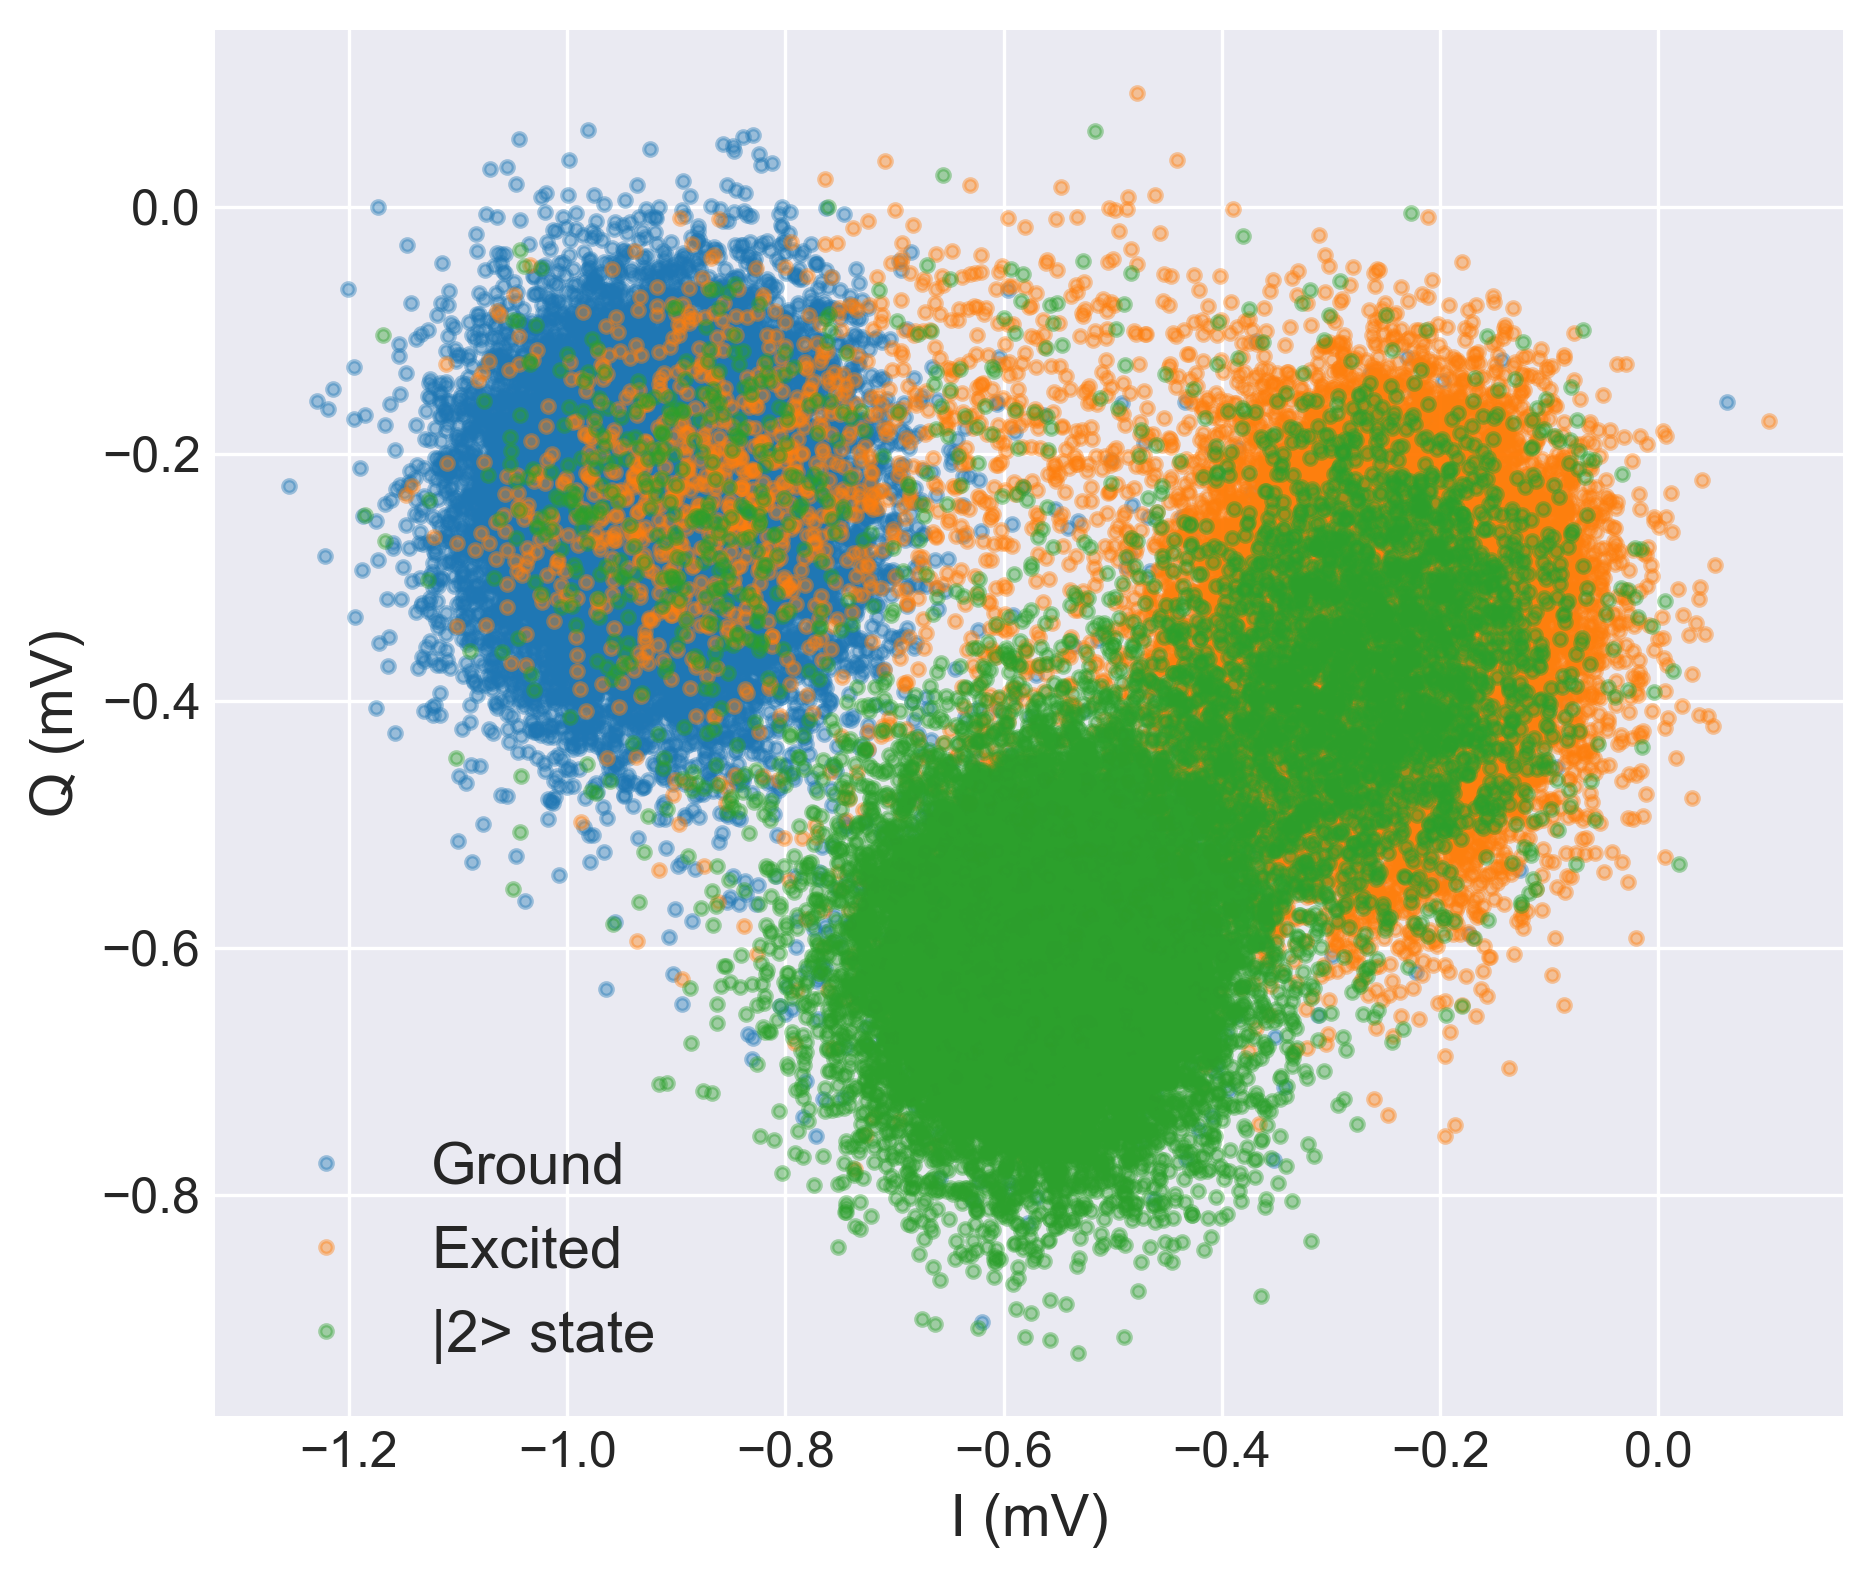

In [90]:
a= load_dataset(523)
# a= load_dataset(488)
a[0].I_e.sel(qubit="q4")
a[0].Q_e.sel(qubit="q4")
a[0].I_g.sel(qubit="q4")
a[0].Q_g.sel(qubit="q4")    
a[0].I_f.sel(qubit="q4")
a[0].Q_f.sel(qubit="q4")

#plot I_f vs Q_f and I_g vs Q_g and I_e vs Q_e
plt.figure(figsize=(7,6),dpi=300)
plt.plot(1e3*a[0].I_g.sel(qubit="q4").values,1e3*a[0].Q_g.sel(qubit="q4"),".",alpha=0.4,label="Ground")
plt.plot(1e3*a[0].I_e.sel(qubit="q4").values,1e3*a[0].Q_e.sel(qubit="q4"),".",alpha=0.4,label="Excited")
plt.plot(1e3*a[0].I_f.sel(qubit="q4").values,1e3*a[0].Q_f.sel(qubit="q4"),".",alpha=0.4,label="|2> state")

plt.xlabel("I (mV)", fontsize=14)
plt.ylabel("Q (mV)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=14)

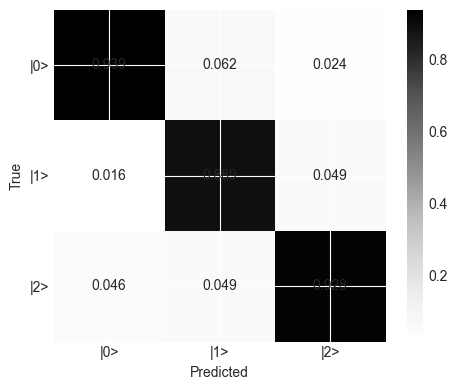

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# confusion matrix extracted
cm = np.array([
    [0.939, 0.062, 0.024],
    [0.016, 0.889, 0.049],
    [0.046, 0.049, 0.928]
])

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm)

# labels
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(["|0>", "|1>", "|2>"])
ax.set_yticklabels(["|0>", "|1>", "|2>"])

# annotate
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cm[i,j]:.3f}", ha='center', va='center')

# ax.set_title("Confusion Matrix Heatmap")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.colorbar(im)
plt.tight_layout()



The data is in a `xarray`, which has a lot of nifty features. For now, we can access the raw data via directly accessing the `values`. 

In [12]:
print("Qubit 2's averaged populations.")
#Note that qubit 2 is index 1!
print(a[0]['state'].values[1])

Qubit 2's averaged populations.


KeyError: "No variable named 'state'. Variables on the dataset include ['N', 'I_g', 'Q_g', 'Q_f', 'I_f', 'Q_e', 'I_e', 'qubit']"

We can plot the data versus time for qubit 2 using

Text(0, 0.5, 'State')

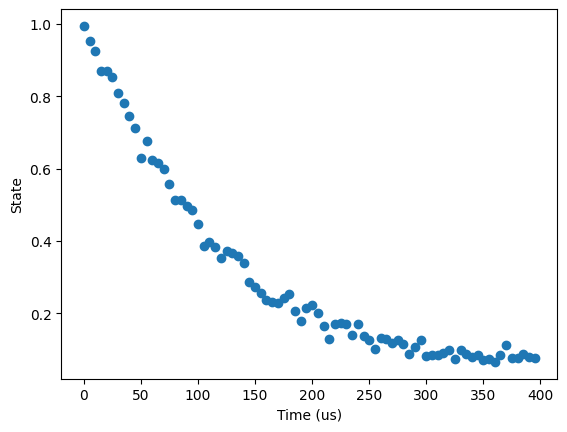

In [ ]:
plt.clf()
plt.plot(a[0]["idle_time"],a[0]['state'].values[1],"o")
plt.xlabel("Time (us)")
plt.ylabel("State")

## Problem #2
Plot the data for the IQ Blobs experiments in datasets 65 and 71. Using `two_state_discriminator` (`from qualang_tools.analysis.discriminator import two_state_discriminator`) find a threshold between `0` and `1` and calculate the confusion matrix. Compare the confusion matrices from experiments 65 and 71. `code/calibration_graph/07c_IQ_Blobs.py` may be helpful here. Plot all IQ blobs and confusion matrices for both experiments. Which qubit, from any experiment, performs the best?



        Fidelity Matrix:
        -----------------
        | 0.496 | 0.504 |
        ----------------
        | 0.480 | 0.520 |
        -----------------
        IQ plane rotated by: 249.2°
        Threshold: -1.495e-04
        Fidelity: 50.8%
        

        Fidelity Matrix:
        -----------------
        | 0.859 | 0.141 |
        ----------------
        | 0.040 | 0.960 |
        -----------------
        IQ plane rotated by: 339.6°
        Threshold: 2.037e-04
        Fidelity: 90.9%
        

        Fidelity Matrix:
        -----------------
        | 0.933 | 0.067 |
        ----------------
        | 0.088 | 0.912 |
        -----------------
        IQ plane rotated by: 344.5°
        Threshold: 5.474e-05
        Fidelity: 92.3%
        

        Fidelity Matrix:
        -----------------
        | 0.941 | 0.059 |
        ----------------
        | 0.190 | 0.810 |
        -----------------
        IQ plane rotated by: 342.2°
        Threshold: 1.397e-04
        Fidelity: 87

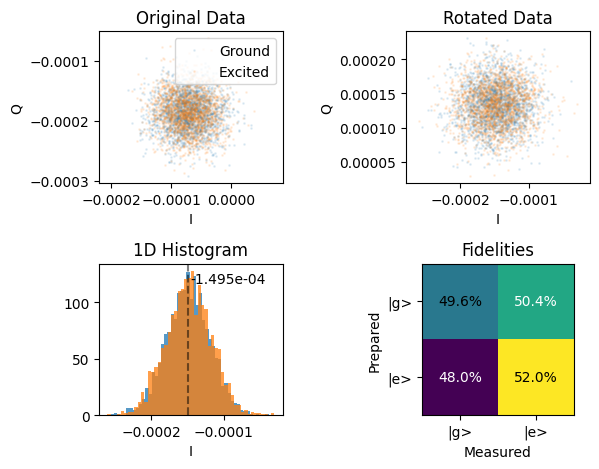

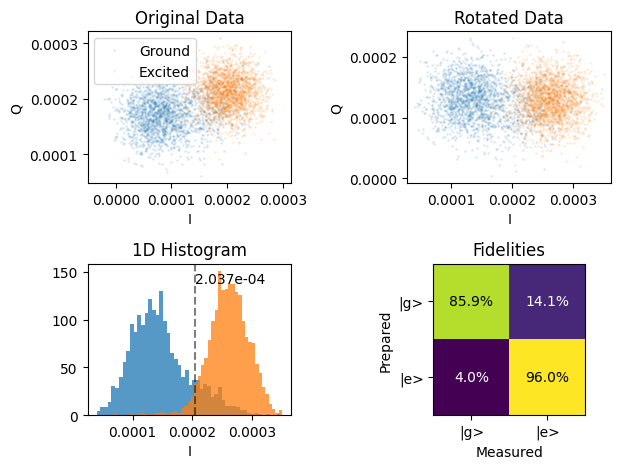

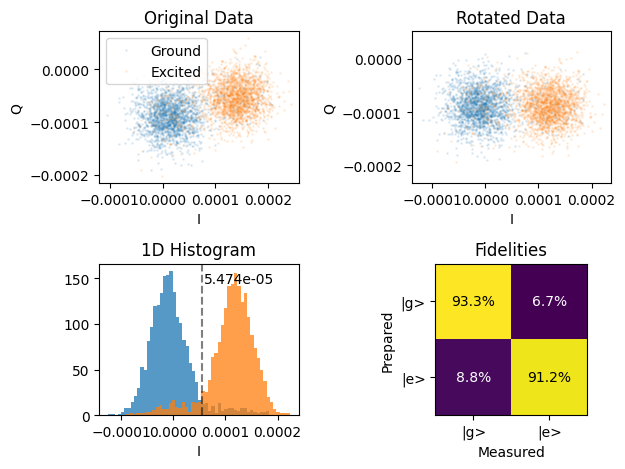

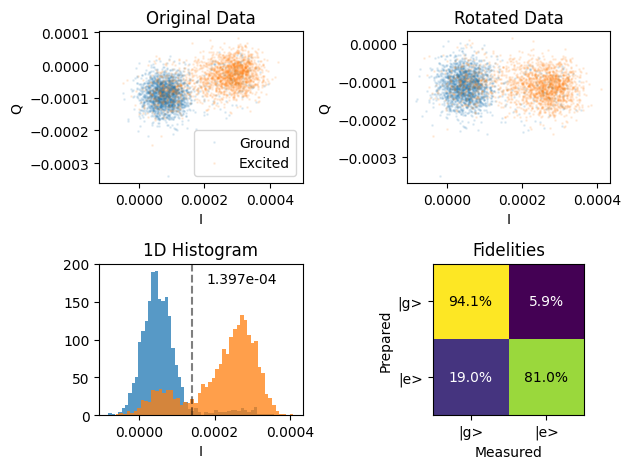

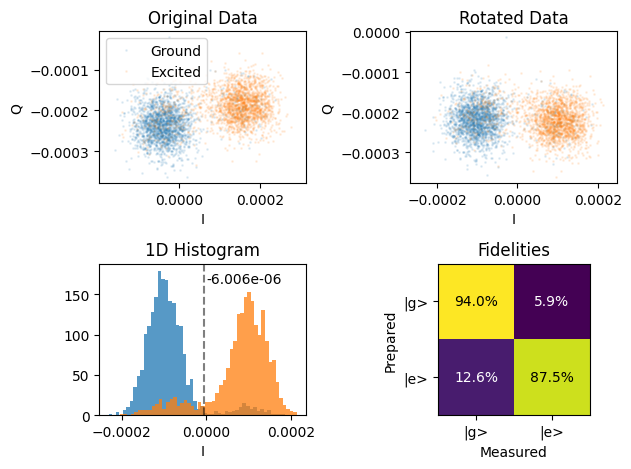

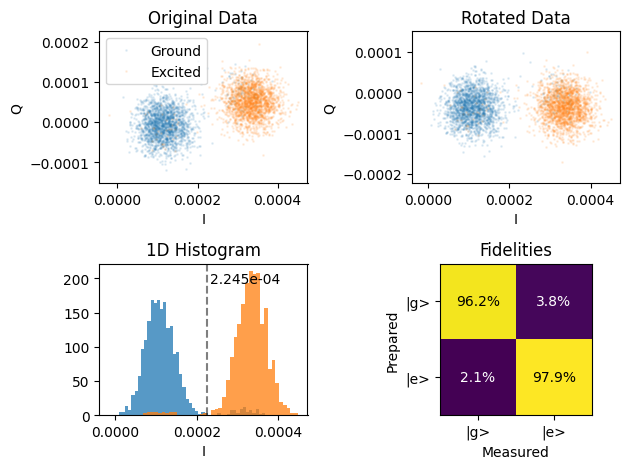

In [ ]:
from qualang_tools.analysis.discriminator import two_state_discriminator
for i in range(1,7):
    two_state_discriminator(b[0].I_g.sel(qubit=f"q{i}").values,
                        b[0].Q_g.sel(qubit=f"q{i}").values,
                        b[0].I_e.sel(qubit=f"q{i}").values,
                        b[0].Q_e.sel(qubit=f"q{i}").values)

Searching in folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-10-14/#71_07b_IQ_Blobs_092032
Loading data from folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-10-14/#71_07b_IQ_Blobs_092032
['ds.h5']

        Fidelity Matrix:
        -----------------
        | 0.533 | 0.467 |
        ----------------
        | 0.526 | 0.474 |
        -----------------
        IQ plane rotated by: 79.2°
        Threshold: -1.115e-04
        Fidelity: 50.4%
        

        Fidelity Matrix:
        -----------------
        | 0.958 | 0.043 |
        ----------------
        | 0.021 | 0.979 |
        -----------------
        IQ plane rotated by: 2.9°
        Threshold: 1.783e-04
        Fidelity: 96.8%
        

        Fidelity Matrix:
        -----------------
        | 0.824 | 0.176 |
        ----------------
        | 0.084 | 0.916 |
        -----------------
        IQ plane rotated by: 336.6°
        Threshold: 2.689e-04
        Fidelity: 87.0%
        

   

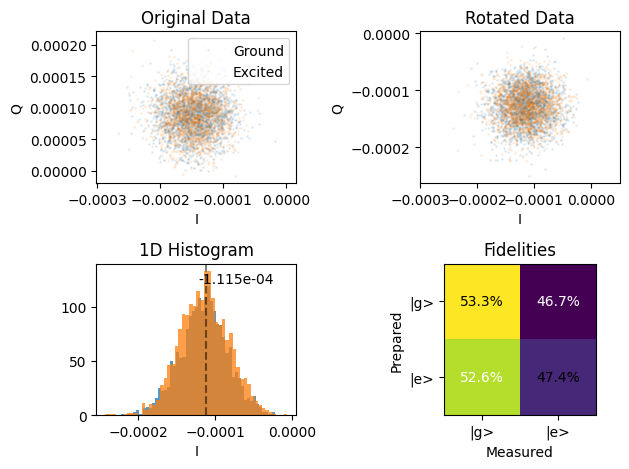

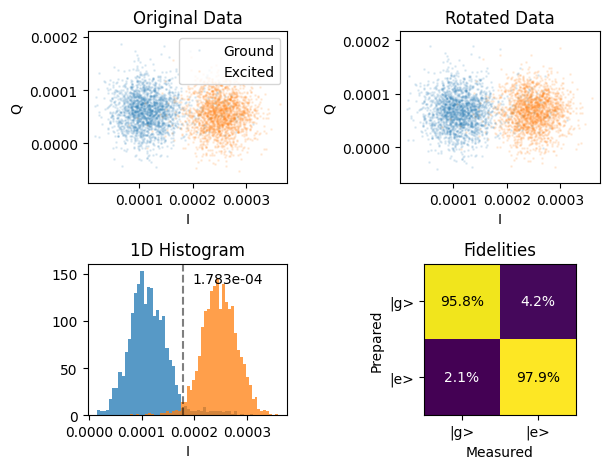

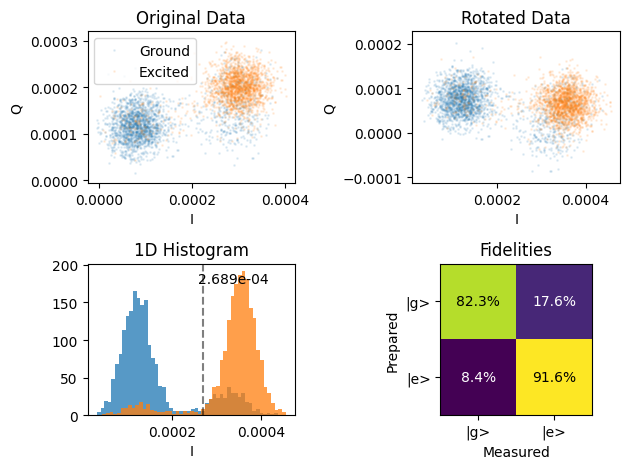

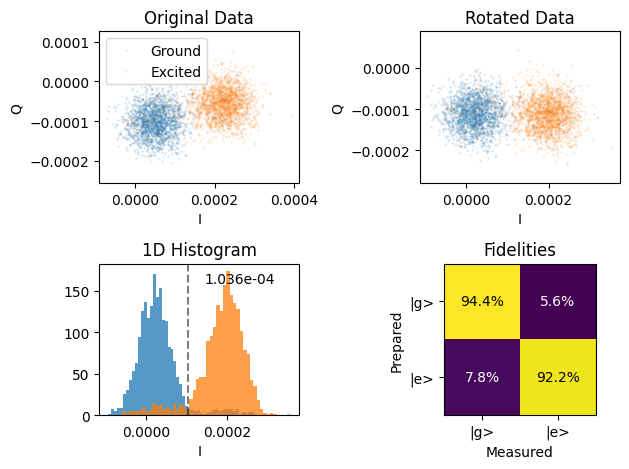

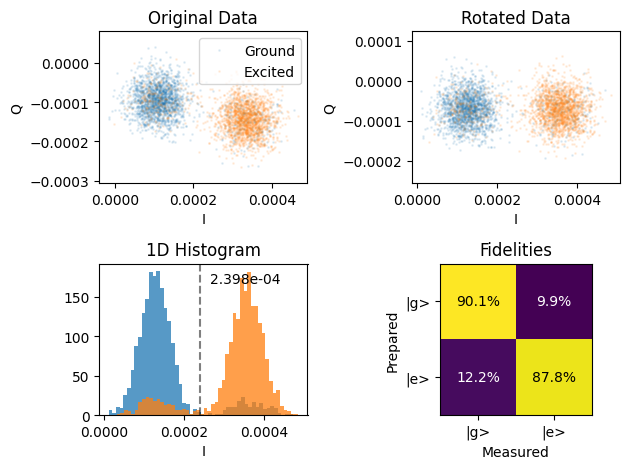

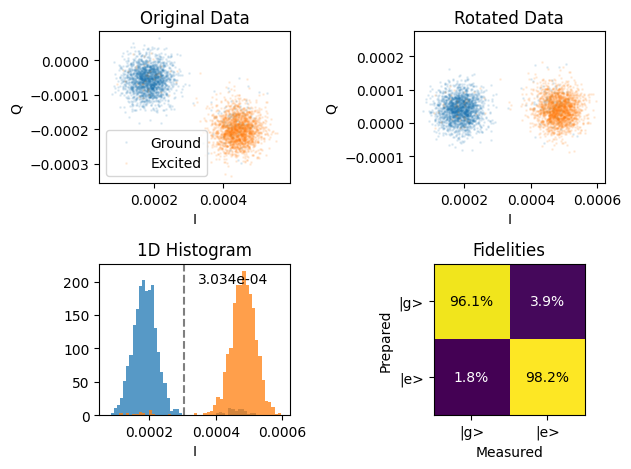

In [ ]:
c = load_dataset(71)
for i in range(1,7):
    two_state_discriminator(c[0].I_g.sel(qubit=f"q{i}").values,
                        c[0].Q_g.sel(qubit=f"q{i}").values,
                        c[0].I_e.sel(qubit=f"q{i}").values,
                        c[0].Q_e.sel(qubit=f"q{i}").values)

## Problem #3
Plot the data for the T1 experiments in datasets 58 and 70. Fit the T1 times for each 'working' qubit using the raw data, as accessed above. Compare the T1s from dataset 58 and dataset 70. You can accomplish this by fitting an exponential decay using, for example, `curve_fit` from `scipy.optimize`. `local_packages/quam_libs/quam_libs/lib/fit.py` gives the example used in `qolab-start`. Compare the T1 times for both experiments. Plot all the T1 plots for both experiments. Which qubit, from any experiment, performs the best?

Searching in folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-10-13/#59_05_T1_160858
Loading data from folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-10-13/#59_05_T1_160858
['ds.h5']


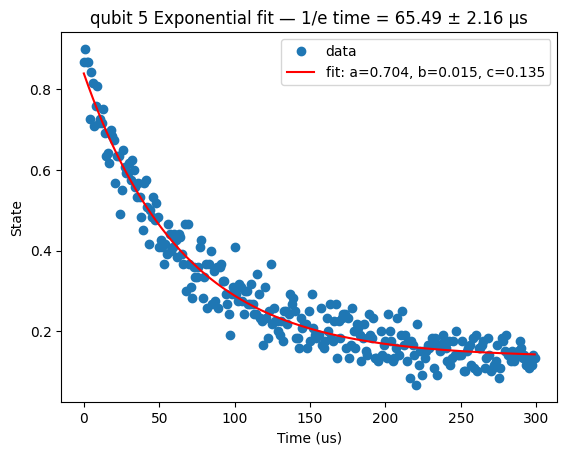

In [ ]:
import scipy.optimize

d_58 = load_dataset(58)


def func(x, a, b, c):
    return a * np.exp(-b * x) + c

xdata = d_58[0]["idle_time"]


popt, pcov = scipy.optimize.curve_fit(func, d_58[0]["idle_time"],d_58[0]['state'].values[0])

plt.plot(d_58[0]["idle_time"],d_58[0]['state'].values[0],"o",label="data")
plt.plot(xdata, func(xdata, *popt), 'r-',
         label='fit: a=%5.3f, b=%5.3f, c=%5.3f' % tuple(popt))

plt.xlabel("Time (us)")
plt.ylabel("State")
plt.legend()
# compute 1/e time and its uncertainty from fit parameter b and show in the title
b = popt[1]
db = np.sqrt(pcov[1, 1])
t1 = 1.0 / b if b != 0 else float("inf")
dt1 = db / b**2 if b != 0 else 0.0
plt.title(f"qubit 5 Exponential fit — 1/e time = {t1:.2f} ± {dt1:.2f} µs")

plt.show()

Searching in folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-10-14/#70_05_T1_091936
Loading data from folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-10-14/#70_05_T1_091936
['ds.h5']


/Users/mohammadkashani/Documents/Qolab/qolab-start/.venv/lib/python3.11/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)


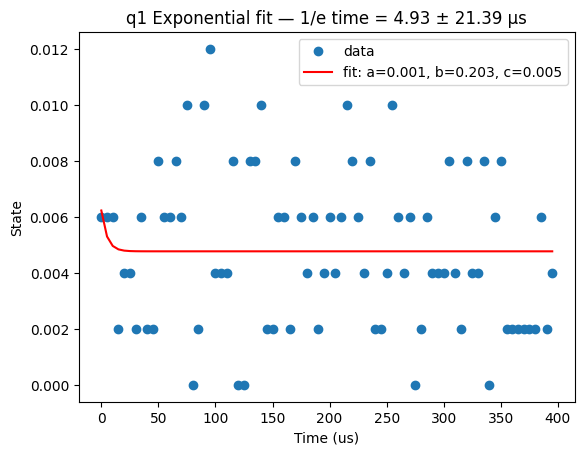

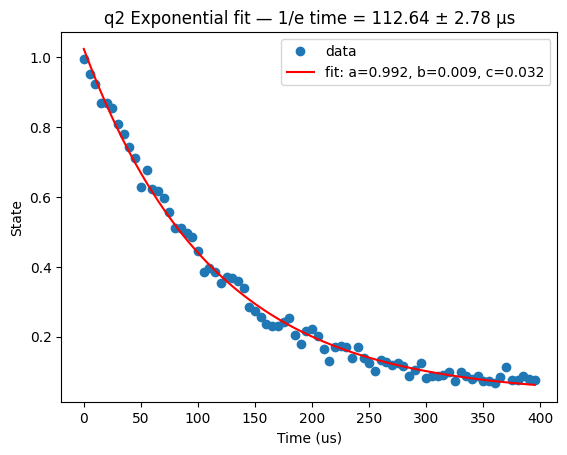

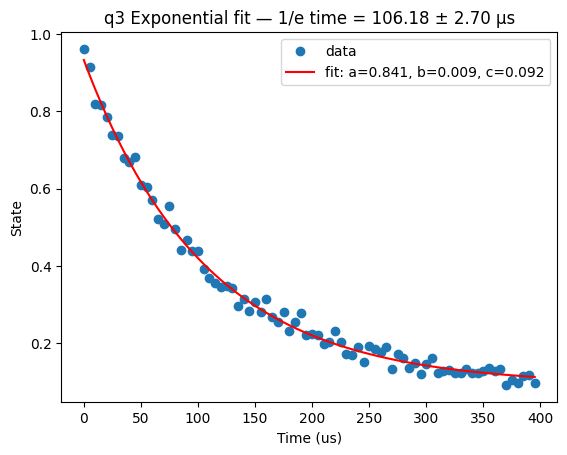

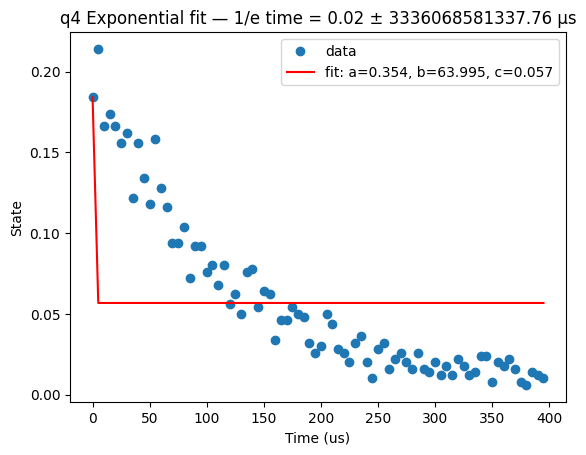

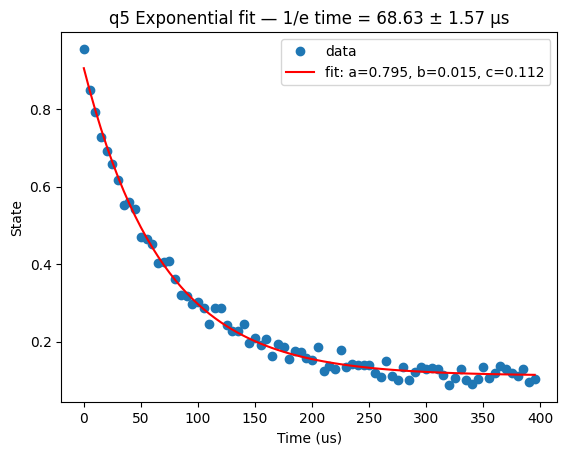

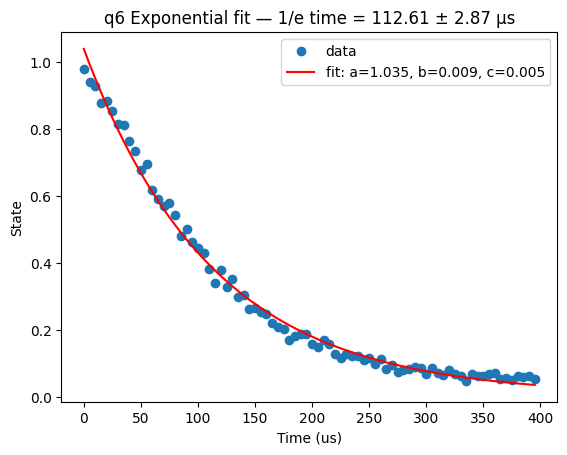

In [ ]:

d_70 = load_dataset(70)
xdata = d_70[0]["idle_time"]

for i in range(0,6):

    popt, pcov = scipy.optimize.curve_fit(func, d_70[0]["idle_time"],d_70[0]['state'].values[i])

    plt.plot(d_70[0]["idle_time"],d_70[0]['state'].values[i],"o",label="data")
    plt.plot(xdata, func(xdata, *popt), 'r-',
            label='fit: a=%5.3f, b=%5.3f, c=%5.3f' % tuple(popt))

    plt.xlabel("Time (us)")
    plt.ylabel("State")
    plt.legend()
    # compute 1/e time and its uncertainty from fit parameter b and show in the title
    b = popt[1]
    db = np.sqrt(pcov[1, 1])
    t1 = 1.0 / b if b != 0 else float("inf")
    dt1 = db / b**2 if b != 0 else 0.0
    plt.title(f"q{i+1} Exponential fit — 1/e time = {t1:.2f} ± {dt1:.2f} µs")

    plt.show()


# Qubit comparison
based on the t1 time the the dataset 70 overall was better tuned. Moreover, in the dataset 70 the qubit 6 is performing better.

# Qeustion 4 

Between the experiments run on 2025/10/13
and 2025/10/14, there was a large change in performance. This can be attributed to
the tune-up of the qubits between 10-13 and 10-14. All of the attributes that go into
this are in the state.json file. Compare the
data/2025-10-13/#58 05 T1 160134/quam state/state.json and
data/2025-10-14/#70 05 T1 091936/quam state/state.json files. What are the
most significant changes between the two? How, in terms of Hamiltonians, resonators,
input/output theory, IQ Blobs, or any other concept we have learned, would that have
had an impact?


In [ ]:
import os
os.system("diff ../data/2025-10-13/#58_05_T1_160134/quam_state/state.json ../data/2025-10-14/#70_05_T1_091936/quam_state/state.json ")

0

# Answer to question 4

I have used the git diff to find the differences. Since the json file is Organized by qubit the changes is also organized by qubit;

Changes (There are some changes with the q1. Since we know that q1 is not working properly I assume that with every different tuning there would a different optimized value and hence I am ignoring all the changes for the q1 qubit.

- The coeficient and the phase of the drag signals have slightly changed. The dragsignals are used to reduce the state leackage probablity of going from |1> to |2>
- In the 'xy' operation parameters there is a saturation value that has changes and I don't know what that is?
- In the 'z' operation parametese there is a independent_offset that has been changes which I assume it is the offset needed for synchronizing the moving frame with the rotating frame for the virtual Z gates.
- The resonators readout values have been changed 
  - "amplitude": 0.13462579588477366, (this is the amplitude of the RF prob signal that is send to measure the state of the qubit)
  - "threshold": 0.00016816928812431303, (this I assume is the threshold of the readout signal that indicates if you are in which state for the IQ blob)
  - "rus_exit_threshold": 9.786276098748899e-05, (no clue)
  - "integration_weights_angle": -10.691949911844818, (no clue)
- "intermediate_frequency": -249085112.0, (this indicates the frequency of the resonator)
- "time_of_flight": 416, (this indicated the time it takes for the RF signal to gets down to the qubit)
- 
- "freq_vs_flux_01_quad_term": -27135854341.73669, (I am not sure what this actually is but I know that the resonating frequncy of the qubit can be modified by the flux that is induced by the flux line)
- "phi0_current": 34.93260262518741, (this must be the current of the flux line)
- "phi0_voltage": 0.6986520525037482, (and this must be the voltage of the flux line that controls the resonance frequncy of the qubit)
- "chi": -600000.0, (have no clue)

whole file changes:
- Analog output control for the qubit 5 has been modified to add a delay
  - "delay": 250,
- And also the mw output has been modified (I don't know what that is)